### 7. 영역처리
* convolution
    * 공간 영역 기반 처리
    * 자바어플리케이션 수업에서 3x3 커널로 하는 곱하기가 이거임
    1. blurring
    2. sharpening
* Edge
    1. 1차 미분
    2. 2차 미분
    3. Canny edge detection
        * 현재 나온 엣지 디텍션중에 제일 좋음

In [ ]:
train_dir = "./data/dogs-vs-cats/train"
test_dir = "./data/dogs-vs-cats/test"

from tensorflow.keras import layers, models, callbacks
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2))) #이미지 축소
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))


c:\Users\user\Desktop\AI특강\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
c:\Users\user\Desktop\AI특강\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [2]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model_path = './dogs-vs-cats.keras'
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5)
checkpoint = callbacks.ModelCheckpoint(filepath=model_path, monitor='val_loss', verbose=1, save_best_only=True)

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(150, 150),
        batch_size=15,
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(150, 150),
        batch_size=15,
        class_mode='binary')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [5]:
history = model.fit(
      train_generator,
      epochs=10,
      validation_data=validation_generator,
      callbacks=[early_stopping, checkpoint])

Epoch 1/10
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.5606 - loss: 0.6771
Epoch 1: val_loss improved from None to 0.63312, saving model to ./dogs-vs-cats.keras

Epoch 1: finished saving model to ./dogs-vs-cats.keras
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 396s 296ms/step - accuracy: 0.6008 - loss: 0.6556 - val_accuracy: 0.6472 - val_loss: 0.6331
Epoch 2/10
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6939 - loss: 0.5789
Epoch 2: val_loss improved from 0.63312 to 0.49170, saving model to ./dogs-vs-cats.keras

Epoch 2: finished saving model to ./dogs-vs-cats.keras
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 101s 76ms/step - accuracy: 0.7128 - loss: 0.5585 - val_accuracy: 0.7604 - val_loss: 0.4917
Epoch 3/10
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7676 - loss: 0.4836
Epoch 3: val_loss improved from 0.49170 to 0.42123, saving model to ./dogs-vs-cats.keras

Epoch 3: finished saving model to ./dogs-vs-cats.keras
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 100s 75ms/step - accurac

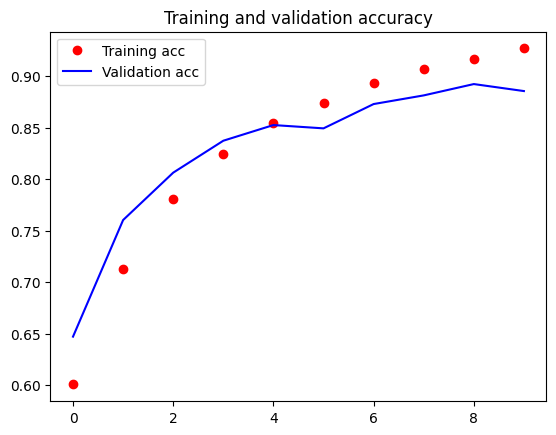

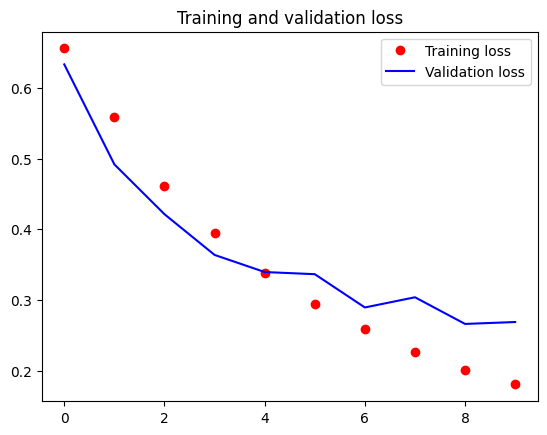

In [6]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'ro', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

In [24]:
from tensorflow.keras import models
model = models.load_model('./dogs-vs-cats.keras')

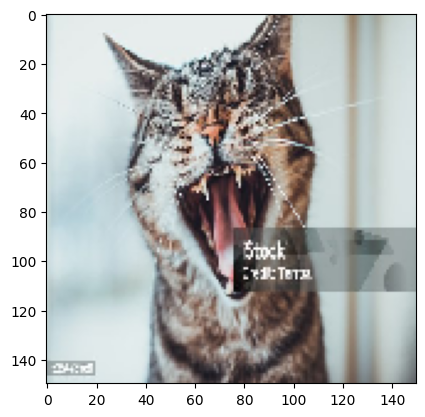

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
prediction:  0.66
It's dog!


In [40]:
from tensorflow.keras.preprocessing import image

import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"]='1'

img_path = "./data/dogs-vs-cats/cat/i.jpg"
img = image.load_img(img_path, target_size=(150, 150))
plt.imshow(img)
plt.show()

img_array = image.img_to_array(img).astype(float) / 255
img_batch = np.expand_dims(img_array, axis=0)


prediction = model.predict(img_batch)
prediction = prediction.flatten()

print("prediction:  %.2f" % prediction[0])

if prediction[0] < 0.5:
    print("It's cat!")
else:
    print("It's dog!")

In [43]:
print("samples:", train_generator.samples)
print("batch_size:", train_generator.batch_size)
print("len(generator):", len(train_generator))

samples: 20000
batch_size: 15
len(generator): 1334
